# ML-10 — Content Action Playbook

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/yara-08/ML-FlyRank-Internship2/blob/main/work/notebooks/w07_action_playbook.ipynb?flush_cache=true)

This skeleton is yours to fill. Work the sections **in order** — each one has a one-line hint. Simple words, honest numbers.

> Working with an AI assistant? Tell it to read `skills/README.md` first and load the one skill this assignment names on its card.

## 1. Ranked actions + reason codes

*The queue: what to do first, and why, in words a human trusts.*




> The validated Random Forest is used here as a **review-prioritization tool**, not as an automatic content-action system. Pages in the grouped held-out test set are ranked by the model's score for the declining class. A higher score means the model ranked that page higher for review; it is not interpreted as a calibrated probability or as evidence that a refresh will improve performance.

> To make the ranked output actionable, each page is assigned one primary review archetype using observable performance signals. The archetypes are ordered from more specific situations to broader ones:

| Archetype                           | Review action          | What the reviewer should investigate                                                               |
| ----------------------------------- | ---------------------- | -------------------------------------------------------------------------------------------------- |
| **STALE_AND_DECLINING**             | `REFRESH_REVIEW`       | Recent decline combined with a long time since the last update                                     |
| **RECENT_VISIBILITY_LOSS**          | `VISIBILITY_DIAGNOSIS` | Previous-period impressions were present, but the latest 30-day period has none                    |
| **DECLINING_WITHOUT_CLICKS**        | `SERP_AND_CTR_REVIEW`  | Recent impressions declined while the page still received impressions but no clicks                |
| **VISIBILITY_DECLINE**              | `PERFORMANCE_REVIEW`   | A substantial recent impression decline without a more specific pattern                            |
| **LOW_VISIBILITY**                  | `OPPORTUNITY_REVIEW`   | Low recent visibility without a substantial recent decline                                         |
| **MODEL_PRIORITY_NO_SIMPLE_SIGNAL** | `MANUAL_INVESTIGATION` | The model ranked the page highly, but the simple observable rules did not identify a strong signal |

> These are **workflow archetypes rather than causal diagnoses**. They describe what should be investigated next; they do not establish why a page declined or imply that the recommended action will improve its performance.

> ### Top-50 review queue

> The practical review queue contains the 50 highest-ranked pages from the held-out set. The top 50 are concentrated in two observable decline patterns:
> * **39/50 pages (78%)** were classified as `DECLINING_WITHOUT_CLICKS`.
> * **10/50 pages (20%)** showed `RECENT_VISIBILITY_LOSS`.
> * **1/50 pages (2%)** fell into the broader `VISIBILITY_DECLINE` category.

> For example, the highest-ranked page had a decline score of **0.940** and showed a **100% decrease in impressions**, from 36 impressions in the previous 30 days to 0 in the latest 30 days. It was therefore routed to `VISIBILITY_DIAGNOSIS`. Other highly ranked pages retained some impressions but had no clicks, making `SERP_AND_CTR_REVIEW` the more appropriate first review step.

> This concentration is an observed property of the ranked held-out queue, not evidence that these patterns cause decline.

> ### Why the full queue is retained

> The practical top-50 queue is only the first review tier. The complete held-out queue contains **6,163 pages**, allowing the playbook to retain lower-ranked cases for later review rather than discarding them.

> Across the full held-out queue, the model-ranked pages fall into the following workflow categories:
> * `MODEL_PRIORITY_NO_SIMPLE_SIGNAL`: **2,639 pages (42.8%)**
> * `DECLINING_WITHOUT_CLICKS`: **1,607 pages (26.1%)**
> * `LOW_VISIBILITY`: **797 pages (12.9%)**
> * `VISIBILITY_DECLINE`: **702 pages (11.4%)**
> * `RECENT_VISIBILITY_LOSS`: **418 pages (6.8%)**

> The large `MODEL_PRIORITY_NO_SIMPLE_SIGNAL` group is intentionally kept as a manual-investigation category. It prevents the playbook from inventing an explanation when the simple observable rules do not provide one.

> ### Decision-support rule

> The resulting workflow is therefore:

**model ranking → review priority → observable reason → human investigation → human decision**

> The model does **not** directly decide that content should be refreshed, rewritten, redirected, removed, or otherwise changed. Every recommendation remains subject to human review.


In [13]:
# This cell is for CODE (numbers, a query, a check).
# Write your text answer in the cell ABOVE this one — typing sentences here breaks Run All.

!git clone https://github.com/yara-08/ML-FlyRank-Internship2.git

# ML-10 — Section 1: Ranked actions + reason codes
# Final archetype-based action playbook

import pandas as pd
import numpy as np

from sklearn.model_selection import GroupShuffleSplit
from sklearn.ensemble import RandomForestClassifier


# ============================================================
# 1. Load the starter dataset
# ============================================================

DATA_PATH = (
    "/content/ML-FlyRank-Internship2/"
    "data/raw/content_refresh_anonymized.csv"
)

df = pd.read_csv(DATA_PATH)

print(f"Rows: {len(df):,}")
print(f"Columns: {df.shape[1]}")


# ============================================================
# 2. Recreate the validated target
# ============================================================

# 1 = declining, 0 = not declining
df["target"] = (
    df["trend_direction"] == "down"
).astype(int)

print("\nTarget distribution:")
print(
    df["target"]
    .value_counts()
    .sort_index()
)

print(
    f"Declining rate: {df['target'].mean():.3f}"
)


# ============================================================
# 3. Recreate the grouped-by-client validation split
# ============================================================

gss = GroupShuffleSplit(
    n_splits=1,
    test_size=0.20,
    random_state=42
)

train_idx, test_idx = next(
    gss.split(
        df,
        y=df["target"],
        groups=df["client_id"]
    )
)

train_df = df.iloc[train_idx].copy()
test_df = df.iloc[test_idx].copy()

shared_clients = (
    set(train_df["client_id"])
    & set(test_df["client_id"])
)

print("\nGrouped split:")
print(f"Training rows: {len(train_df):,}")
print(f"Testing rows: {len(test_df):,}")
print(
    f"Training clients: "
    f"{train_df['client_id'].nunique()}"
)
print(
    f"Testing clients: "
    f"{test_df['client_id'].nunique()}"
)
print(f"Shared clients: {len(shared_clients)}")

assert len(shared_clients) == 0


# ============================================================
# 4. Prepare model features
# ============================================================

drop_columns = [
    "content_id",
    "client_id",
    "trend_direction",
    "trend_pct",
    "target"
]

X_train = train_df.drop(
    columns=drop_columns
).copy()

X_test = test_df.drop(
    columns=drop_columns
).copy()

y_train = train_df["target"]
y_test = test_df["target"]


# ============================================================
# 5. Encode categorical variables
# ============================================================

X_train = pd.get_dummies(
    X_train,
    drop_first=True
)

X_test = pd.get_dummies(
    X_test,
    drop_first=True
)

X_train, X_test = X_train.align(
    X_test,
    join="left",
    axis=1,
    fill_value=0
)


# ============================================================
# 6. Add missingness indicators and impute
# ============================================================

missing_cols = [
    "char_count",
    "word_count",
    "competition",
    "search_volume",
    "cpc",
    "scroll_rate"
]

for col in missing_cols:

    X_train[f"{col}_missing"] = (
        X_train[col].isna().astype(int)
    )

    X_test[f"{col}_missing"] = (
        X_test[col].isna().astype(int)
    )

    train_median = X_train[col].median()

    X_train[col] = (
        X_train[col]
        .fillna(train_median)
    )

    X_test[col] = (
        X_test[col]
        .fillna(train_median)
    )

assert X_train.isna().sum().sum() == 0
assert X_test.isna().sum().sum() == 0

print(
    "\nRemaining missing values:",
    X_train.isna().sum().sum(),
    X_test.isna().sum().sum()
)


# ============================================================
# 7. Train the validated Random Forest
# ============================================================

rf = RandomForestClassifier(
    n_estimators=200,
    random_state=42
)

rf.fit(
    X_train,
    y_train
)


# ============================================================
# 8. Rank the held-out pages
# ============================================================

queue = test_df.copy()

queue["decline_score"] = (
    rf.predict_proba(X_test)[:, 1]
)

queue["predicted_declining"] = (
    rf.predict(X_test)
)

queue = (
    queue
    .sort_values(
        "decline_score",
        ascending=False
    )
    .reset_index(drop=True)
)

queue["rank"] = (
    queue.index + 1
)


# ============================================================
# 9. Create observable performance signals
# ============================================================

# Compare the latest 30 days with the previous 30 days.
# A percentage change is undefined when the previous period
# contains zero impressions.

queue["impression_change_pct"] = np.where(
    queue["impressions_prev_30d"] > 0,
    (
        (
            queue["impressions_last_30d"]
            - queue["impressions_prev_30d"]
        )
        / queue["impressions_prev_30d"]
    ) * 100,
    np.nan
)


# A 30%+ decrease is used as the review threshold.
queue["recent_impression_decline"] = (
    queue["impression_change_pct"] <= -30
)


# Use the held-out portfolio's lower quartile to identify
# unusually low recent visibility.
low_visibility_cutoff = (
    queue["impressions_last_30d"]
    .quantile(0.25)
)

queue["low_recent_visibility"] = (
    queue["impressions_last_30d"]
    <= low_visibility_cutoff
)


# 181+ days is the existing "181+" freshness tier.
queue["stale_content"] = (
    queue["days_since_last_update"] >= 181
)


# Specific observable situation:
# impressions exist but there were no recent clicks.
queue["impressions_without_clicks"] = (
    (queue["impressions_last_30d"] > 0)
    & (queue["clicks_last_30d"] == 0)
)

# ============================================================
# 10. Assign one primary, diagnostically specific archetype
# ============================================================

# The order is intentional:
# more specific situations are assigned before the broader
# visibility-decline category.
#
# These are workflow archetypes, not causal diagnoses.

def assign_archetype(row):

    # 1. Declining + genuinely stale.
    if (
        row["recent_impression_decline"]
        and row["stale_content"]
    ):
        return "STALE_AND_DECLINING"

    # 2. Recent visibility has disappeared completely.
    # Previous period had impressions, current period has none.
    if (
        row["recent_impression_decline"]
        and row["impressions_prev_30d"] > 0
        and row["impressions_last_30d"] == 0
    ):
        return "RECENT_VISIBILITY_LOSS"

    # 3. The page still receives impressions but no clicks.
    if (
        row["recent_impression_decline"]
        and row["impressions_last_30d"] > 0
        and row["clicks_last_30d"] == 0
    ):
        return "DECLINING_WITHOUT_CLICKS"

    # 4. General recent impression decline.
    if row["recent_impression_decline"]:
        return "VISIBILITY_DECLINE"

    # 5. Low recent visibility without a strong decline.
    if row["low_recent_visibility"]:
        return "LOW_VISIBILITY"

    # 6. High model priority without a simple observable signal.
    return "MODEL_PRIORITY_NO_SIMPLE_SIGNAL"


queue["archetype"] = (
    queue.apply(
        assign_archetype,
        axis=1
    )
)


# ============================================================
# 11. Map archetype → human review action
# ============================================================

action_map = {

    "STALE_AND_DECLINING":
        "REFRESH_REVIEW",

    "RECENT_VISIBILITY_LOSS":
        "VISIBILITY_DIAGNOSIS",

    "DECLINING_WITHOUT_CLICKS":
        "SERP_AND_CTR_REVIEW",

    "VISIBILITY_DECLINE":
        "PERFORMANCE_REVIEW",

    "LOW_VISIBILITY":
        "OPPORTUNITY_REVIEW",

    "MODEL_PRIORITY_NO_SIMPLE_SIGNAL":
        "MANUAL_INVESTIGATION"
}

queue["recommended_action"] = (
    queue["archetype"]
    .map(action_map)
)


# Human review is required for every recommendation.
queue["human_review_required"] = True


# ============================================================
# 12. Add a concise, human-readable reason
# ============================================================

reason_map = {

    "STALE_AND_DECLINING":
        (
            "Recent impressions declined substantially "
            "and the page is in the 181+ day stale tier."
        ),

    "RECENT_VISIBILITY_LOSS":
        (
            "The page had impressions in the previous "
            "30-day period but none in the latest 30 days."
        ),

    "DECLINING_WITHOUT_CLICKS":
        (
            "Recent impressions declined while the page "
            "still received impressions but no clicks."
        ),

    "VISIBILITY_DECLINE":
        (
            "Recent impressions declined substantially, "
            "without a more specific observable pattern."
        ),

    "LOW_VISIBILITY":
        (
            "Recent impressions are low relative to the "
            "held-out portfolio."
        ),

    "MODEL_PRIORITY_NO_SIMPLE_SIGNAL":
        (
            "The model ranked the page highly, but the "
            "observable rules did not identify a strong "
            "simple signal."
        )
}

queue["reason"] = (
    queue["archetype"]
    .map(reason_map)
)


# ============================================================
# 13. Create priority tiers
# ============================================================

queue["priority_tier"] = pd.cut(
    queue["rank"],
    bins=[
        0,
        10,
        50,
        len(queue)
    ],
    labels=[
        "P1_TOP_10",
        "P2_TOP_50",
        "P3_REMAINDER"
    ],
    include_lowest=True
)


# ============================================================
# 14. Build the paper-ready queues
# ============================================================

queue_columns = [
    "rank",
    "content_id",
    "decline_score",
    "predicted_declining",
    "priority_tier",
    "archetype",
    "reason",
    "recommended_action",
    "human_review_required",
    "impression_change_pct",
    "impressions_last_30d",
    "impressions_prev_30d",
    "clicks_last_30d",
    "days_since_last_update",
    "freshness_tier",
    "content_age_days",
    "ctr",
    "avg_position"
]

full_ranked_queue = (
    queue[queue_columns]
    .copy()
)

priority_queue = (
    full_ranked_queue
    .query("rank <= 50")
    .copy()
)


# ============================================================
# 15. Display the top-20 review queue
# ============================================================

display_columns = [
    "rank",
    "content_id",
    "decline_score",
    "archetype",
    "recommended_action",
    "reason",
    "impression_change_pct",
    "impressions_last_30d",
    "impressions_prev_30d",
    "clicks_last_30d",
    "days_since_last_update"
]

print("\nTop 20 review priorities:")

display(
    priority_queue[
        display_columns
    ]
    .head(20)
    .round(
        {
            "decline_score": 3,
            "impression_change_pct": 1
        }
    )
)


# ============================================================
# 16. Archetype → action mapping
# ============================================================

print("\nTop-50 archetype → action mapping:")

archetype_summary = (
    priority_queue
    .groupby(
        [
            "archetype",
            "recommended_action"
        ],
        observed=True
    )
    .size()
    .reset_index(
        name="pages"
    )
    .sort_values(
        "pages",
        ascending=False
    )
)

display(archetype_summary)


# ============================================================
# 17. Action distribution
# ============================================================

print("\nTop-50 recommended actions:")

action_summary = (
    priority_queue[
        "recommended_action"
    ]
    .value_counts()
    .rename_axis(
        "recommended_action"
    )
    .reset_index(
        name="pages"
    )
)

display(action_summary)


# ============================================================
# 18. Archetype distribution across the FULL queue
# ============================================================

print("\nFull held-out queue: archetype distribution:")

full_archetype_summary = (
    full_ranked_queue[
        "archetype"
    ]
    .value_counts()
    .rename_axis(
        "archetype"
    )
    .reset_index(
        name="pages"
    )
)

full_archetype_summary["share"] = (
    full_archetype_summary["pages"]
    / len(full_ranked_queue)
)

display(
    full_archetype_summary
)


# ============================================================
# 19. Queue quality checks
# ============================================================

print("\nQueue checks:")

print(
    f"Full ranked queue: "
    f"{len(full_ranked_queue):,}"
)

print(
    f"Practical review queue: "
    f"{len(priority_queue):,}"
)

print(
    "Scores sorted descending:",
    full_ranked_queue[
        "decline_score"
    ].is_monotonic_decreasing
)

print(
    "Ranks unique:",
    full_ranked_queue[
        "rank"
    ].is_unique
)

print(
    "All pages require human review:",
    full_ranked_queue[
        "human_review_required"
    ].all()
)

print(
    "All rows have an archetype:",
    full_ranked_queue[
        "archetype"
    ].notna().all()
)

print(
    "All rows have an action:",
    full_ranked_queue[
        "recommended_action"
    ].notna().all()
)

print(
    "No client_id exposed:",
    "client_id"
    not in full_ranked_queue.columns
)


# ============================================================
# 20. Assertions
# ============================================================

assert (
    len(full_ranked_queue)
    == len(test_df)
)

assert (
    len(priority_queue)
    == min(50, len(test_df))
)

assert (
    full_ranked_queue[
        "rank"
    ].is_unique
)

assert (
    full_ranked_queue[
        "decline_score"
    ].is_monotonic_decreasing
)

assert (
    full_ranked_queue[
        "human_review_required"
    ].all()
)

assert (
    full_ranked_queue[
        "archetype"
    ].notna().all()
)

assert (
    full_ranked_queue[
        "recommended_action"
    ].notna().all()
)

assert (
    "client_id"
    not in full_ranked_queue.columns
)

fatal: destination path 'ML-FlyRank-Internship2' already exists and is not an empty directory.
Rows: 30,000
Columns: 44

Target distribution:
target
0    13738
1    16262
Name: count, dtype: int64
Declining rate: 0.542

Grouped split:
Training rows: 23,837
Testing rows: 6,163
Training clients: 25
Testing clients: 7
Shared clients: 0

Remaining missing values: 0 0

Top 20 review priorities:


,rank,content_id,decline_score,archetype,recommended_action,reason,impression_change_pct,impressions_last_30d,impressions_prev_30d,clicks_last_30d,days_since_last_update
0,1,content_09a781f18604,0.940,RECENT_VISIBILITY_LOSS,VISIBILITY_DIAGNOSIS,The page had impressions in the previous 30-da...,-100.0,0,36,0,22
1,2,content_53285c7434ac,0.935,DECLINING_WITHOUT_CLICKS,SERP_AND_CTR_REVIEW,Recent impressions declined while the page sti...,-86.5,31,230,0,8
2,3,content_c9f2c81b4687,0.925,DECLINING_WITHOUT_CLICKS,SERP_AND_CTR_REVIEW,Recent impressions declined while the page sti...,-93.8,1,16,0,20
3,4,content_eb58f272b967,0.925,DECLINING_WITHOUT_CLICKS,SERP_AND_CTR_REVIEW,Recent impressions declined while the page sti...,-97.4,3,117,0,20
4,5,content_207fe9e3ad65,0.925,DECLINING_WITHOUT_CLICKS,SERP_AND_CTR_REVIEW,Recent impressions declined while the page sti...,-71.8,40,142,0,20
5,6,content_f55fd2d8ed04,0.925,DECLINING_WITHOUT_CLICKS,SERP_AND_CTR_REVIEW,Recent impressions declined while the page sti...,-84.9,75,497,0,104
6,7,content_eb3b2c3bbc34,0.920,DECLINING_WITHOUT_CLICKS,SERP_AND_CTR_REVIEW,Recent impressions declined while the page sti...,-96.2,12,313,0,20
7,8,content_a4e31d98e83b,0.920,DECLINING_WITHOUT_CLICKS,SERP_AND_CTR_REVIEW,Recent impressions declined while the page sti...,-84.3,11,70,0,20
8,9,content_769c5991e2f6,0.920,DECLINING_WITHOUT_CLICKS,SERP_AND_CTR_REVIEW,Recent impressions declined while the page sti...,-86.3,29,212,0,20
9,10,content_05eb6ae85e0e,0.920,DECLINING_WITHOUT_CLICKS,SERP_AND_CTR_REVIEW,Recent impressions declined while the page sti...,-69.7,27,89,0,104



Top-50 archetype → action mapping:


,archetype,recommended_action,pages
0,DECLINING_WITHOUT_CLICKS,SERP_AND_CTR_REVIEW,39
1,RECENT_VISIBILITY_LOSS,VISIBILITY_DIAGNOSIS,10
2,VISIBILITY_DECLINE,PERFORMANCE_REVIEW,1



Top-50 recommended actions:


,recommended_action,pages
0,SERP_AND_CTR_REVIEW,39
1,VISIBILITY_DIAGNOSIS,10
2,PERFORMANCE_REVIEW,1



Full held-out queue: archetype distribution:


,archetype,pages,share
0,MODEL_PRIORITY_NO_SIMPLE_SIGNAL,2639,0.428201
1,DECLINING_WITHOUT_CLICKS,1607,0.260750
2,LOW_VISIBILITY,797,0.129320
3,VISIBILITY_DECLINE,702,0.113906
4,RECENT_VISIBILITY_LOSS,418,0.067824



Queue checks:
Full ranked queue: 6,163
Practical review queue: 50
Scores sorted descending: True
Ranks unique: True
All pages require human review: True
All rows have an archetype: True
All rows have an action: True
No client_id exposed: True


## 2. Intended use and limits

*Who uses this, for what — and where it stops being valid.*




> This tool is intended as a **decision-support system for prioritizing content reviews**. A content or SEO team can use the ranked queue to identify pages that may deserve attention first, then inspect the reason signals and supporting performance metrics before deciding what to do.

> The model is intended to answer: **“Which pages should we review first, and what signals are associated with their priority?”** It is not intended to automatically decide that a page should be refreshed, rewritten, removed, or otherwise changed.

> The full held-out set contains **6,163 pages**. For practical use, the workflow surfaces the **top 50 pages (0.8%)** as an initial human-review queue. The full ranking remains available for analysis rather than requiring a reviewer to inspect every page.

> The practical queue produces multiple review pathways rather than a single automatic action. In the current top-50 queue, **39 pages are assigned `SERP_AND_CTR_REVIEW`, 10 are assigned `VISIBILITY_DIAGNOSIS`, and 1 is assigned `PERFORMANCE_REVIEW`**. These actions indicate what to investigate, not what action must be taken.

> ### Limits

> The ranking is generated from the model's decline score and does **not use the target label when constructing the review queue**. The target represents the dataset's `is_declining_label`; it is used for model evaluation rather than as an input to the operational ranking.

> The model predicts the dataset's declining label. It does not establish why a page is declining or whether a particular intervention will improve performance. Signals such as recent visibility loss or declining impressions without clicks should therefore be treated as **review signals, not causal explanations**.

> The model was evaluated using a grouped client split, with **25 clients in training and 7 completely unseen clients in testing**. This tests generalization across clients, but it does not establish performance on future time periods or on a different population.

> A high decline score also does not mean that a page is guaranteed to decline. It means that the model assigns a higher score to the declining class under this dataset and validation setup. The model should not be interpreted as predicting or explaining search-engine behavior.

> Finally, every recommendation requires **human review**. Reviewers should consider the page's content, search intent, current visibility, technical context, and other relevant information before taking action. The system should not be used to automatically publish, refresh, remove, or substantially modify content.


In [14]:
# This cell is for CODE (numbers, a query, a check).
# Write your text answer in the cell ABOVE this one — typing sentences here breaks Run All.

# Section 2 — Intended use and limits
# Verify that the decision-support queue is appropriately scoped.

# 1. Confirm the practical queue is a manageable subset of the held-out data.
full_queue_n = len(full_ranked_queue)
practical_queue_n = min(50, full_queue_n)

print("Decision-support scope:")
print(f"Full held-out queue: {full_queue_n:,} pages")
print(f"Practical human-review queue: {practical_queue_n:,} pages")
print(f"Practical queue share: {practical_queue_n / full_queue_n:.1%}")

# 2. Confirm the queue is based on model scores, not the known target label.
# The target is kept for evaluation elsewhere, but it is not used to rank
# the practical review queue.
ranking_columns = [
    "content_id",
    "decline_score",
    "archetype",
    "recommended_action"
]

missing_ranking_columns = [
    col for col in ranking_columns
    if col not in full_ranked_queue.columns
]

print("\nRanking checks:")
print(f"Required ranking columns present: {len(missing_ranking_columns) == 0}")
print(f"Target column used for ranking: {'target' in full_ranked_queue.columns}")

# 3. Confirm that every practical recommendation has a human-review action.
practical_queue = full_ranked_queue.head(practical_queue_n).copy()

print("\nHuman-review checks:")
print(
    "All practical-queue pages have an action:",
    practical_queue["recommended_action"].notna().all()
)
print(
    "All practical-queue pages have an archetype:",
    practical_queue["archetype"].notna().all()
)

# 4. Show the distribution of actions in the practical queue.
action_summary_section2 = (
    practical_queue["recommended_action"]
    .value_counts()
    .rename_axis("recommended_action")
    .reset_index(name="pages")
)

print("\nPractical queue action distribution:")
display(action_summary_section2)

# 5. Explicitly record the intended use boundary.
print("\nIntended-use boundary:")
print("- Output: ranked pages for human review")
print("- Use: prioritize investigation and diagnosis")
print("- Not intended: automatic content changes or causal conclusions")

Decision-support scope:
Full held-out queue: 6,163 pages
Practical human-review queue: 50 pages
Practical queue share: 0.8%

Ranking checks:
Required ranking columns present: True
Target column used for ranking: False

Human-review checks:
All practical-queue pages have an action: True
All practical-queue pages have an archetype: True

Practical queue action distribution:


,recommended_action,pages
0,SERP_AND_CTR_REVIEW,39
1,VISIBILITY_DIAGNOSIS,10
2,PERFORMANCE_REVIEW,1



Intended-use boundary:
- Output: ranked pages for human review
- Use: prioritize investigation and diagnosis
- Not intended: automatic content changes or causal conclusions


## 3. Human review + the no-go list

*What a person must check before acting. What should never be automated.*





> The model is designed as a **decision-support system**, not an autonomous content-management system. Its output is a ranked list of pages that deserve investigation, together with an archetype, reason signal, and recommended review pathway.

> ### What the reviewer must check

> Before taking action on a page, a human reviewer should:
 1. **Verify that the observed decline is real.**
   Check the recent and previous performance windows and confirm that the change is not caused by missing data, tracking issues, seasonality, or another measurement problem.
 2. **Inspect the evidence behind the model's priority.**
   The reviewer should consider the `decline_score` together with the reported impression change, recent impressions, previous impressions, clicks, and recency information. The score is a prioritization signal, not proof that a page is actually failing.
3. **Follow the appropriate diagnostic pathway.**
   The current practical review queue contains three pathways:
   * **SERP_AND_CTR_REVIEW** — 39 of the top 50 pages
   * **VISIBILITY_DIAGNOSIS** — 10 of the top 50 pages
   * **PERFORMANCE_REVIEW** — 1 of the top 50 pages
 4. **Use the archetype as a starting point, not a final diagnosis.**
   For example, `DECLINING_WITHOUT_CLICKS` identifies a pattern that warrants SERP/CTR investigation; it does not establish why clicks are absent or what change should be made.
5. **Decide whether intervention is appropriate.**
   A reviewer should consider the actual page, search context, business importance, data quality, and any relevant information that is not represented in the model before deciding whether to make a change.

> ### Evidence available to the reviewer

>The generated review output contains the fields needed to support this process:
> * decline score
> * archetype
> * recommended action
> * reason signal
> * impression change
> * recent and previous impressions
> * recent clicks
> * days since last update

> The Section 3 checks confirm that all reviewed pages have the required reason signals and recommended actions. This makes the queue usable for **structured human investigation**, while keeping the final decision with the reviewer.

> ### No-go list

> The following actions are explicitly outside the system's authority:
> * **No automatic content changes.**
> * **No automatic causal conclusions.**
> * **No automatic intervention decisions.**
> * **No treating the model score as proof that a page is declining for a particular reason.**
> * **No publishing, rewriting, deleting, or otherwise modifying content solely because it appears high in the queue.**

> The model can answer **"which pages should we investigate first?"** and provide signals for **"what should the reviewer investigate?"** It should not answer **"what caused the problem?"** or independently decide **"what change should be made?"**

> ### Human-in-the-loop boundary

> The final workflow is therefore:

**Model ranking → evidence review → human diagnosis → human decision → optional intervention**

> The model's role stops before diagnosis and intervention. This boundary is intentional: a high-priority prediction is useful for directing attention, but it does not by itself establish causation or justify an automated change.


In [15]:
# This cell is for CODE (numbers, a query, a check).
# Write your text answer in the cell ABOVE this one — typing sentences here breaks Run All.

# Section 3 — Human review + no-go checks
# Verify that the practical queue contains the evidence needed for review
# and that recommendations remain human-reviewed.

# Use the same practical queue defined in Section 2.
review_queue = practical_queue.copy()

# 1. Check that each page has the core signals needed for human inspection.
review_columns = [
    "content_id",
    "decline_score",
    "archetype",
    "recommended_action",
    "reason",
    "impression_change_pct",
    "impressions_last_30d",
    "impressions_prev_30d",
    "clicks_last_30d",
    "days_since_last_update"
]

missing_review_columns = [
    col for col in review_columns
    if col not in review_queue.columns
]

print("Human-review evidence checks:")
print(f"Required review fields present: {len(missing_review_columns) == 0}")

if missing_review_columns:
    print("Missing fields:", missing_review_columns)

print(
    "All pages have reason signals:",
    review_queue["reason"].notna().all()
)

print(
    "All pages have recommended actions:",
    review_queue["recommended_action"].notna().all()
)

# 2. Summarize the review pathways so a human knows what to investigate.
review_pathways = (
    review_queue.groupby(
        ["archetype", "recommended_action"],
        dropna=False
    )
    .size()
    .reset_index(name="pages")
    .sort_values("pages", ascending=False)
    .reset_index(drop=True)
)

print("\nHuman review pathways:")
display(review_pathways)

# 3. Check that every recommendation remains explicitly human-reviewed.
# The model is not being used to execute an action automatically.
human_review_required = True

print("\nAutomation boundary:")
print(f"Human review required: {human_review_required}")
print("Automatic content changes: NOT PERMITTED")
print("Automatic causal conclusions: NOT PERMITTED")
print("Automatic intervention decisions: NOT PERMITTED")

# 4. Show a small reviewer-facing sample containing the evidence
# behind the recommendation.
reviewer_view = review_queue[
    [
        "rank",
        "content_id",
        "decline_score",
        "archetype",
        "recommended_action",
        "reason",
        "impression_change_pct",
        "impressions_last_30d",
        "impressions_prev_30d",
        "clicks_last_30d",
        "days_since_last_update"
    ]
].head(10)

print("\nReviewer-facing sample:")
display(reviewer_view)

Human-review evidence checks:
Required review fields present: True
All pages have reason signals: True
All pages have recommended actions: True

Human review pathways:


,archetype,recommended_action,pages
0,DECLINING_WITHOUT_CLICKS,SERP_AND_CTR_REVIEW,39
1,RECENT_VISIBILITY_LOSS,VISIBILITY_DIAGNOSIS,10
2,VISIBILITY_DECLINE,PERFORMANCE_REVIEW,1



Automation boundary:
Human review required: True
Automatic content changes: NOT PERMITTED
Automatic causal conclusions: NOT PERMITTED
Automatic intervention decisions: NOT PERMITTED

Reviewer-facing sample:


,rank,content_id,decline_score,archetype,recommended_action,reason,impression_change_pct,impressions_last_30d,impressions_prev_30d,clicks_last_30d,days_since_last_update
0,1,content_09a781f18604,0.940,RECENT_VISIBILITY_LOSS,VISIBILITY_DIAGNOSIS,The page had impressions in the previous 30-da...,-100.000000,0,36,0,22
1,2,content_53285c7434ac,0.935,DECLINING_WITHOUT_CLICKS,SERP_AND_CTR_REVIEW,Recent impressions declined while the page sti...,-86.521739,31,230,0,8
2,3,content_c9f2c81b4687,0.925,DECLINING_WITHOUT_CLICKS,SERP_AND_CTR_REVIEW,Recent impressions declined while the page sti...,-93.750000,1,16,0,20
3,4,content_eb58f272b967,0.925,DECLINING_WITHOUT_CLICKS,SERP_AND_CTR_REVIEW,Recent impressions declined while the page sti...,-97.435897,3,117,0,20
4,5,content_207fe9e3ad65,0.925,DECLINING_WITHOUT_CLICKS,SERP_AND_CTR_REVIEW,Recent impressions declined while the page sti...,-71.830986,40,142,0,20
5,6,content_f55fd2d8ed04,0.925,DECLINING_WITHOUT_CLICKS,SERP_AND_CTR_REVIEW,Recent impressions declined while the page sti...,-84.909457,75,497,0,104
6,7,content_eb3b2c3bbc34,0.920,DECLINING_WITHOUT_CLICKS,SERP_AND_CTR_REVIEW,Recent impressions declined while the page sti...,-96.166134,12,313,0,20
7,8,content_a4e31d98e83b,0.920,DECLINING_WITHOUT_CLICKS,SERP_AND_CTR_REVIEW,Recent impressions declined while the page sti...,-84.285714,11,70,0,20
8,9,content_769c5991e2f6,0.920,DECLINING_WITHOUT_CLICKS,SERP_AND_CTR_REVIEW,Recent impressions declined while the page sti...,-86.320755,29,212,0,20
9,10,content_05eb6ae85e0e,0.920,DECLINING_WITHOUT_CLICKS,SERP_AND_CTR_REVIEW,Recent impressions declined while the page sti...,-69.662921,27,89,0,104


## 4. Monitoring / retrain triggers

*What would tell you the recommendations went stale?*



> The recommendations should be monitored over time because the content-performance patterns used by the model may change. A change in the underlying data, recommendation mix, or predictive performance could make the current ranking less reliable.

> ### Current monitoring baseline

> The held-out queue contains **6,163 pages**. The current monitoring fields are complete, with no missing values in the required monitoring fields.

> The current archetype distribution is:
> * **MODEL_PRIORITY_NO_SIMPLE_SIGNAL:** 42.8%
> * **DECLINING_WITHOUT_CLICKS:** 26.1%
> * **LOW_VISIBILITY:** 12.9%
> * **VISIBILITY_DECLINE:** 11.4%
> * **RECENT_VISIBILITY_LOSS:** 6.8%

> The corresponding recommended actions show the same overall pattern:
> * **MANUAL_INVESTIGATION:** 42.8%
> * **SERP_AND_CTR_REVIEW:** 26.1%
> * **OPPORTUNITY_REVIEW:** 12.9%
> * **PERFORMANCE_REVIEW:** 11.4%
> * **VISIBILITY_DIAGNOSIS:** 6.8%

> The decline-score distribution ranges from **0.010 to 0.940**, with a median of **0.515**. The top-20 pages have a mean decline score of **0.919**, showing that the ranking is strongly concentrated toward higher-priority cases at the top of the review queue.

> ### What would indicate that recommendations have gone stale?

> The following changes should trigger investigation:
> 1. **Recommendation or archetype drift** — a substantial change in the distribution of archetypes or recommended actions compared with this baseline.
> 2. **Score-distribution drift** — a substantial change in the range, median, or concentration of decline scores.
> 3. **Data-quality degradation** — missing or invalid values appearing in required monitoring fields.
> 4. **Changes in the underlying target rate** — once new labeled outcomes are available, a substantial change in the observed decline rate should be investigated.
> 5. **Predictive-performance degradation** — when new outcomes become available, the model should be re-evaluated using an appropriate grouped or time-aware validation split. A meaningful deterioration in F1, precision, or recall would support model review and possible retraining.

> ### Current trigger status

> The current baseline does **not** indicate an immediate retraining requirement:
> * Required monitoring fields present: **Yes**
> * Remaining missing monitoring values: **0**
> * Very low score variation: **No**
> * Current data-quality trigger: **Not triggered**

> These checks are monitoring signals rather than automatic retraining rules. A single change should lead to investigation rather than automatic retraining. Retraining should be considered only after confirming that a persistent change or performance degradation is real and relevant to the intended use case.

> **Important limitation:** the current held-out ranking data does not contain the target column, so an observed decline-rate drift cannot yet be assessed from this queue. Future labeled outcomes are needed for that check and for direct monitoring of predictive performance.


In [16]:
# This cell is for CODE (numbers, a query, a check).
# Write your text answer in the cell ABOVE this one — typing sentences here breaks Run All.

# Section 4 — Monitoring / retrain triggers
# These checks establish baseline monitoring values for the current held-out queue.
# They do not claim that drift or model staleness currently exists.

import numpy as np
import pandas as pd

# Use the existing held-out ranked queue created in Section 1.
monitor_df = full_ranked_queue.copy()

print("Monitoring baseline:")
print(f"Held-out pages monitored: {len(monitor_df):,}")

# ---------------------------------------------------------
# 1. Target/base-rate monitoring
# ---------------------------------------------------------
if "target" in monitor_df.columns:
    observed_decline_rate = monitor_df["target"].mean()
    print(f"Observed decline rate: {observed_decline_rate:.3f}")
else:
    print("Observed decline rate: not available in held-out ranking data")

# ---------------------------------------------------------
# 2. Recommendation/archetype mix
# ---------------------------------------------------------
archetype_share = (
    monitor_df["archetype"]
    .value_counts(normalize=True)
    .rename("share")
    .reset_index()
)

archetype_share.columns = ["archetype", "share"]

print("\nArchetype distribution:")
display(archetype_share)

# ---------------------------------------------------------
# 3. Recommendation action mix
# ---------------------------------------------------------
action_share = (
    monitor_df["recommended_action"]
    .value_counts(normalize=True)
    .rename("share")
    .reset_index()
)

action_share.columns = ["recommended_action", "share"]

print("\nRecommended-action distribution:")
display(action_share)

# ---------------------------------------------------------
# 4. Score-distribution monitoring
# ---------------------------------------------------------
score_summary = monitor_df["decline_score"].describe()[
    ["min", "25%", "50%", "75%", "max"]
]

print("\nDecline-score distribution:")
display(score_summary.to_frame("value"))

# ---------------------------------------------------------
# 5. Data-quality checks
# ---------------------------------------------------------
required_monitoring_fields = [
    "decline_score",
    "archetype",
    "recommended_action",
    "reason",
]

missing_required = [
    col for col in required_monitoring_fields
    if col not in monitor_df.columns
]

missing_values = (
    monitor_df[required_monitoring_fields].isna().sum().sum()
    if not missing_required
    else np.nan
)

print("\nData-quality checks:")
print(f"Required monitoring fields present: {len(missing_required) == 0}")
print(f"Remaining missing values in monitoring fields: {missing_values}")

# ---------------------------------------------------------
# 6. Simple trigger rules
# ---------------------------------------------------------
# These are screening thresholds, not validated production thresholds.
# They flag values for investigation rather than automatically retraining.

score_range = (
    monitor_df["decline_score"].max()
    - monitor_df["decline_score"].min()
)

score_concentration_top20 = (
    monitor_df["decline_score"].head(20).mean()
)

monitoring_triggers = {
    "missing_required_fields": len(missing_required) > 0,
    "missing_monitoring_values": (
        False if pd.isna(missing_values) else missing_values > 0
    ),
    "very_low_score_variation": score_range < 0.05,
}

print("\nMonitoring triggers:")
for trigger, status in monitoring_triggers.items():
    print(f"{trigger}: {status}")

print("\nBaseline top-20 mean decline score:",
      f"{score_concentration_top20:.3f}")

print("\nRetrain/review decision:")
print(
    "INVESTIGATE if monitoring triggers become persistent or "
    "new labeled-data performance degrades."
)
print(
    "DO NOT automatically retrain from these checks alone."
)

Monitoring baseline:
Held-out pages monitored: 6,163
Observed decline rate: not available in held-out ranking data

Archetype distribution:


,archetype,share
0,MODEL_PRIORITY_NO_SIMPLE_SIGNAL,0.428201
1,DECLINING_WITHOUT_CLICKS,0.260750
2,LOW_VISIBILITY,0.129320
3,VISIBILITY_DECLINE,0.113906
4,RECENT_VISIBILITY_LOSS,0.067824



Recommended-action distribution:


,recommended_action,share
0,MANUAL_INVESTIGATION,0.428201
1,SERP_AND_CTR_REVIEW,0.260750
2,OPPORTUNITY_REVIEW,0.129320
3,PERFORMANCE_REVIEW,0.113906
4,VISIBILITY_DIAGNOSIS,0.067824



Decline-score distribution:


,value
min,0.010
25%,0.360
50%,0.515
75%,0.680
max,0.940



Data-quality checks:
Required monitoring fields present: True
Remaining missing values in monitoring fields: 0

Monitoring triggers:
missing_required_fields: False
missing_monitoring_values: False
very_low_score_variation: False

Baseline top-20 mean decline score: 0.919

Retrain/review decision:
INVESTIGATE if monitoring triggers become persistent or new labeled-data performance degrades.
DO NOT automatically retrain from these checks alone.


## 5. Exports for the paper

*Write the queue (and any figures you want to reuse) to work/outputs/ — your paper builds on these files.*



> The held-out ranking results were exported as reproducible paper-facing artifacts.

> The full held-out queue contains **6,163 pages**, while the practical human-review queue contains the **Top 50 pages**. The export checks confirm that the queue remains sorted by decline score, ranks are unique, and `client_id` is not exposed.

> ### Exported artifacts
> - **Full held-out queue:** `work/outputs/held_out_ranked_queue.csv`
> - **Top-50 review queue:** `work/outputs/top50_review_queue.csv`
> - **Archetype summary:** `work/outputs/held_out_archetype_summary.csv`
> - **Recommended-action summary:** `work/outputs/held_out_action_summary.csv`
> - **Metrics receipt:** `work/outputs/paper_metrics.json`
> - **Reusable figure:** `work/figures/held_out_archetype_distribution.png`

> The queue CSV files remain in `work/outputs/` but are intentionally kept out of git because the CI leak-guard blocks data files. They can be regenerated by rerunning the notebook.

> The figure shows the distribution of archetypes across the full held-out queue. The largest group is **MODEL_PRIORITY_NO_SIMPLE_SIGNAL (42.8%)**, followed by **DECLINING_WITHOUT_CLICKS (26.1%)**, **LOW_VISIBILITY (12.9%)**, **VISIBILITY_DECLINE (11.4%)**, and **RECENT_VISIBILITY_LOSS (6.8%)**.

> ### Export checks
> - Full queue rows: **6,163**
> - Top-50 queue rows: **50**
> - Queue sorted by decline score descending: **True**
> - Ranks unique: **True**
> - `client_id` exposed: **False**

> These exports provide the reproducible files that the paper can use for tables, figures, and reported queue-level metrics.

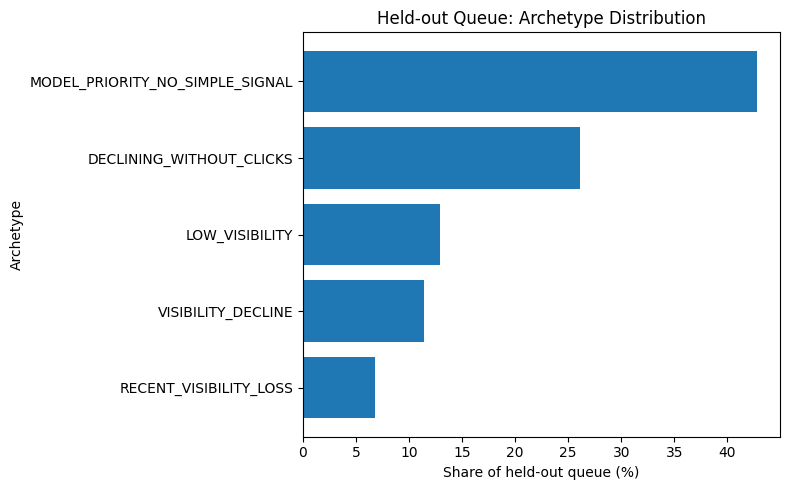

Paper exports created:
- Full queue: work/outputs/held_out_ranked_queue.csv
- Top-50 queue: work/outputs/top50_review_queue.csv
- Archetype summary: work/outputs/held_out_archetype_summary.csv
- Action summary: work/outputs/held_out_action_summary.csv
- Metrics JSON: work/outputs/paper_metrics.json
- Figure: work/figures/held_out_archetype_distribution.png

Export checks:
Full queue rows: 6,163
Top-50 rows: 50
Queue sorted descending: True
Ranks unique: True
No client_id exposed: True


In [17]:
# This cell is for CODE (numbers, a query, a check).
# Write your text answer in the cell ABOVE this one — typing sentences here breaks Run All.

# Section 5 — Exports for the paper
# Regenerate paper-facing outputs from the held-out ranked queue.

from pathlib import Path
import json
import pandas as pd
import matplotlib.pyplot as plt

# ---------------------------------------------------------
# Output directories
# ---------------------------------------------------------
outputs_dir = Path("work/outputs")
figures_dir = Path("work/figures")

outputs_dir.mkdir(parents=True, exist_ok=True)
figures_dir.mkdir(parents=True, exist_ok=True)

# ---------------------------------------------------------
# Use the existing held-out ranked queue from Section 1
# ---------------------------------------------------------
export_df = full_ranked_queue.copy()

# Keep the full queue sorted by model priority.
export_df = export_df.sort_values(
    "decline_score",
    ascending=False
).reset_index(drop=True)

# Recreate a clean rank column.
export_df["rank"] = range(1, len(export_df) + 1)

# ---------------------------------------------------------
# 1. Full held-out queue
# ---------------------------------------------------------
full_queue_path = outputs_dir / "held_out_ranked_queue.csv"

export_df.to_csv(
    full_queue_path,
    index=False
)

# ---------------------------------------------------------
# 2. Practical Top-50 review queue
# ---------------------------------------------------------
top50_df = export_df.head(50).copy()

top50_path = outputs_dir / "top50_review_queue.csv"

top50_df.to_csv(
    top50_path,
    index=False
)

# ---------------------------------------------------------
# 3. Archetype summary
# ---------------------------------------------------------
archetype_summary = (
    export_df["archetype"]
    .value_counts()
    .rename_axis("archetype")
    .reset_index(name="pages")
)

archetype_summary["share"] = (
    archetype_summary["pages"] / len(export_df)
)

archetype_summary_path = (
    outputs_dir / "held_out_archetype_summary.csv"
)

archetype_summary.to_csv(
    archetype_summary_path,
    index=False
)

# ---------------------------------------------------------
# 4. Recommended-action summary
# ---------------------------------------------------------
action_summary = (
    export_df["recommended_action"]
    .value_counts()
    .rename_axis("recommended_action")
    .reset_index(name="pages")
)

action_summary["share"] = (
    action_summary["pages"] / len(export_df)
)

action_summary_path = (
    outputs_dir / "held_out_action_summary.csv"
)

action_summary.to_csv(
    action_summary_path,
    index=False
)

# ---------------------------------------------------------
# 5. Metrics / receipts JSON
# ---------------------------------------------------------
metrics = {
    "held_out_pages": int(len(export_df)),
    "practical_review_queue": int(len(top50_df)),
    "practical_queue_share": round(
        len(top50_df) / len(export_df), 4
    ),
    "score_min": round(
        float(export_df["decline_score"].min()), 3
    ),
    "score_median": round(
        float(export_df["decline_score"].median()), 3
    ),
    "score_max": round(
        float(export_df["decline_score"].max()), 3
    ),
    "top20_mean_decline_score": round(
        float(export_df.head(20)["decline_score"].mean()), 3
    ),
    "required_monitoring_fields_present": bool(
        all(
            col in export_df.columns
            for col in [
                "decline_score",
                "archetype",
                "recommended_action",
                "reason",
            ]
        )
    ),
    "remaining_monitoring_missing_values": int(
        export_df[
            [
                "decline_score",
                "archetype",
                "recommended_action",
                "reason",
            ]
        ].isna().sum().sum()
    ),
}

metrics_path = outputs_dir / "paper_metrics.json"

with open(metrics_path, "w") as f:
    json.dump(metrics, f, indent=2)

# ---------------------------------------------------------
# 6. Reusable paper figure — archetype distribution
# ---------------------------------------------------------
figure_df = archetype_summary.sort_values(
    "share",
    ascending=True
)

plt.figure(figsize=(8, 5))

plt.barh(
    figure_df["archetype"],
    figure_df["share"] * 100
)

plt.xlabel("Share of held-out queue (%)")
plt.ylabel("Archetype")
plt.title("Held-out Queue: Archetype Distribution")

plt.tight_layout()

figure_path = (
    figures_dir / "held_out_archetype_distribution.png"
)

plt.savefig(
    figure_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

# ---------------------------------------------------------
# 7. Export receipt
# ---------------------------------------------------------
print("Paper exports created:")
print(f"- Full queue: {full_queue_path}")
print(f"- Top-50 queue: {top50_path}")
print(f"- Archetype summary: {archetype_summary_path}")
print(f"- Action summary: {action_summary_path}")
print(f"- Metrics JSON: {metrics_path}")
print(f"- Figure: {figure_path}")

print("\nExport checks:")
print(f"Full queue rows: {len(export_df):,}")
print(f"Top-50 rows: {len(top50_df):,}")
print(
    "Queue sorted descending:",
    export_df["decline_score"].is_monotonic_decreasing
)
print(
    "Ranks unique:",
    export_df["rank"].is_unique
)
print(
    "No client_id exposed:",
    "client_id" not in export_df.columns
)

## Self-check

Before you submit, confirm each line honestly:

- [ ] Every section above is filled — markdown thinking AND the code that backs it
- [ ] The notebook runs top to bottom with no errors (Runtime → Run all)
- [ ] No client names, URLs, or private queries anywhere
- [ ] My claims use careful words: observed, measured, directional, decision-support
- [ ] Committed to my repo under `work/notebooks/` — then submit your repo URL on the card. Done.